# Compare results with UCBshif and Sparta+ chemical shift forward models

```
# Copyright 2025 Peptone Ltd
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
import os.path

from peptonebench.config import DB_CS, DB_SAXS
from peptonebench.plotting import get_lowess_fit

pep_cs_df = pd.read_csv(
    DB_CS,
    index_col="label",
    converters={"gscores": lambda s: np.asarray(json.loads(s), dtype=float)},
)

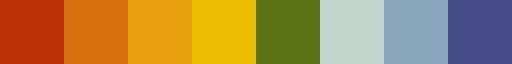

In [2]:
# set bigger font sizes
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIG_SIZE = 16

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIG_SIZE)  # fontsize of the figure title

g_name = {
    "alphafold": "AlphaFold2",
    "bioemu": "BioEmu",
    "boltz1x": "Boltz1x",
    "boltz2": "Boltz2",
    "esmflow": "ESMFlow",
    "esmflow_md": "ESMFlow-MD",
    "esmfold": "ESMFold",
    "idp-o": "IDP-o",
    "idpfold": "IDPFold",
    "idpgan": "idpGAN",
    "idpsam": "idpSAM",
    "peptron_stable_pdb_20250809_236800": "PepTron-base",
    "peptron_stable_pdb_idrome_20250812_256000": "PepTron",
    "random_coil": "Random Coil",
}

from matplotlib.colors import rgb2hex
from pypalettes import load_cmap

cmap = load_cmap("VanGogh")
colors = {
    "esmfold": rgb2hex(cmap(1)),
    "esmflow": rgb2hex(cmap(2)),
    "idp-o": rgb2hex(cmap(3)),
    "peptron_stable_pdb_idrome_20250812_256000": rgb2hex(cmap(5)),
}
cmap = load_cmap("VanGogh2")
colors.update(
    {
        "boltz2": rgb2hex(cmap(0)),
        "alphafold": rgb2hex(cmap(2)),
        "bioemu": rgb2hex(cmap(4)),
    }
)
cmap

In [3]:
generators = [
    "alphafold",
    "esmfold",
    "idp-o",
    "idpgan",
    "idpfold",
    "idpsam",
    "boltz1x",
    "boltz2",
    "esmflow",
    "bioemu",
    "peptron_stable_pdb_20250809_236800",
    "peptron_stable_pdb_idrome_20250812_256000",
    "esmflow_md",
]

info_cs = {}
for cs_tag in ["UCBshift", "Sparta+"]:
    info_cs[cs_tag] = {}
    base_path = "../../PEP_ensembles"
    for generator in tqdm(generators):
        filename = f"{base_path}/PEP_ChemicalShifts/generated_ensembles-moderate-v2/{generator}/rew_info-{cs_tag}.csv"
        if not os.path.exists(filename):
            !PeptoneBench -f {os.path.dirname(filename)}
        info_cs[cs_tag][generator] = pd.read_csv(filename, index_col="label")


100%|██████████| 13/13 [00:00<00:00, 659.07it/s]


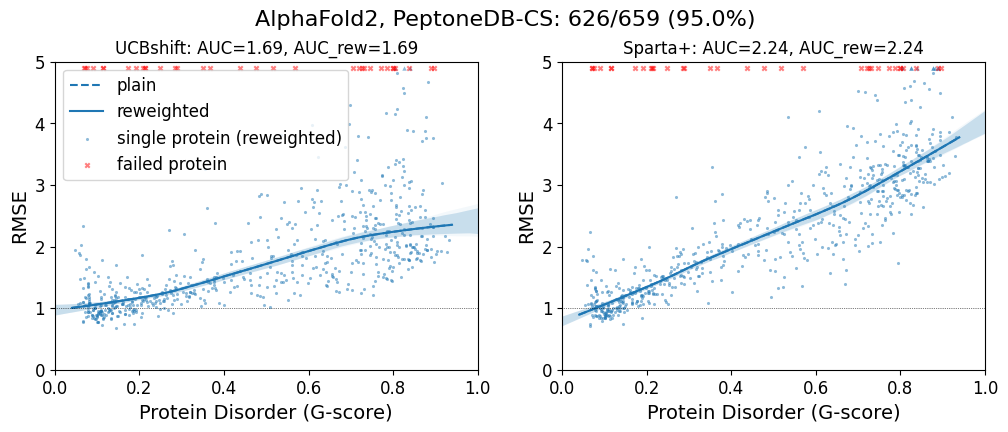

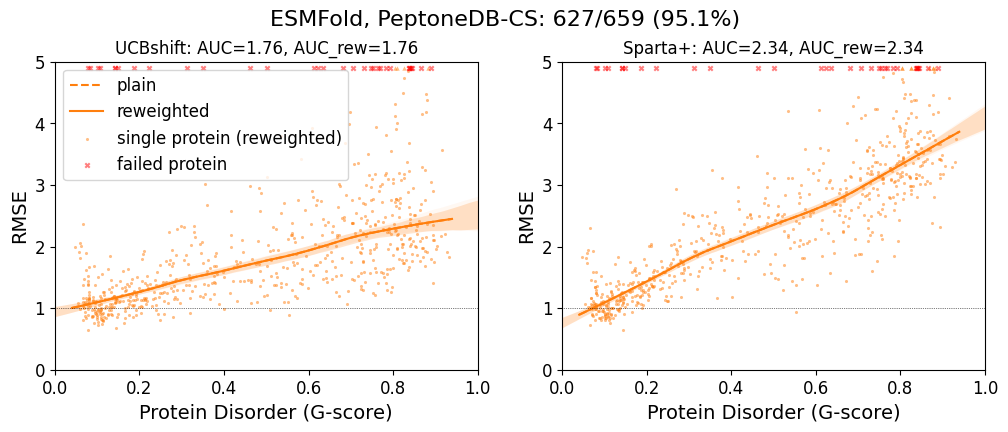

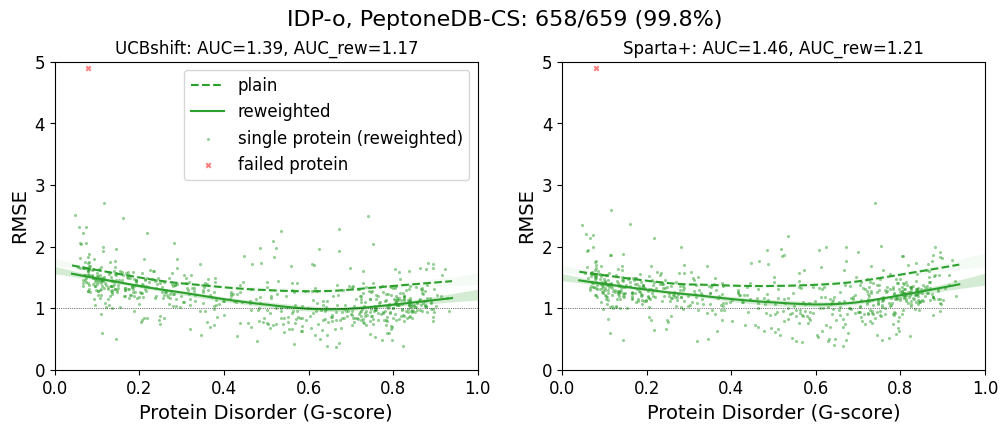

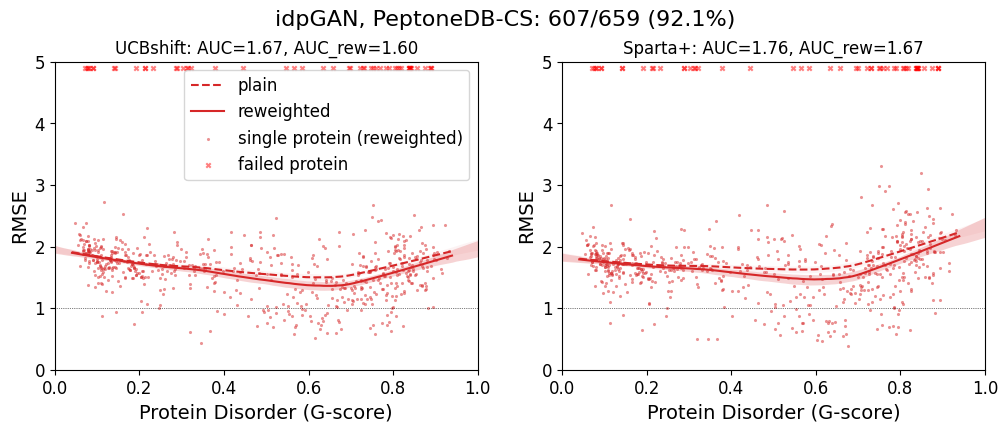

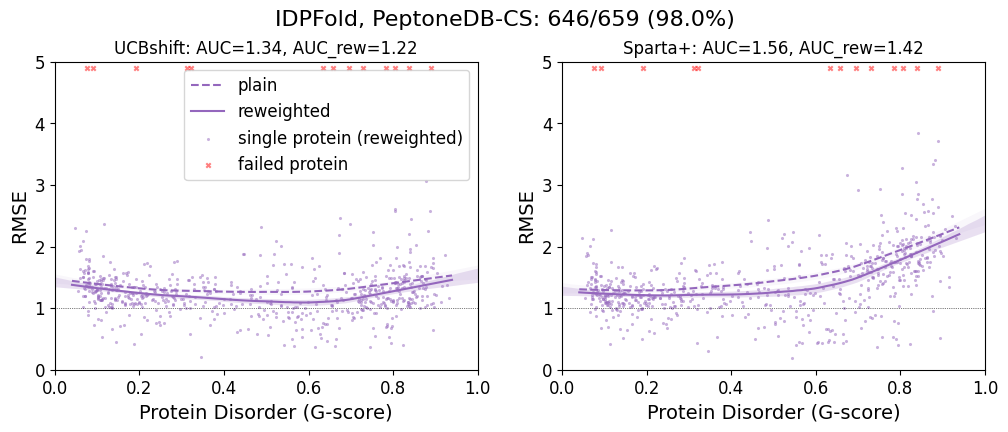

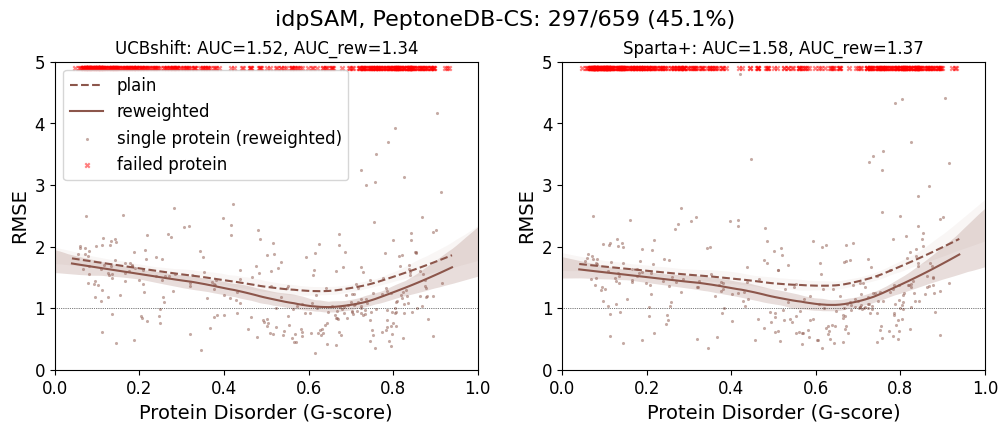

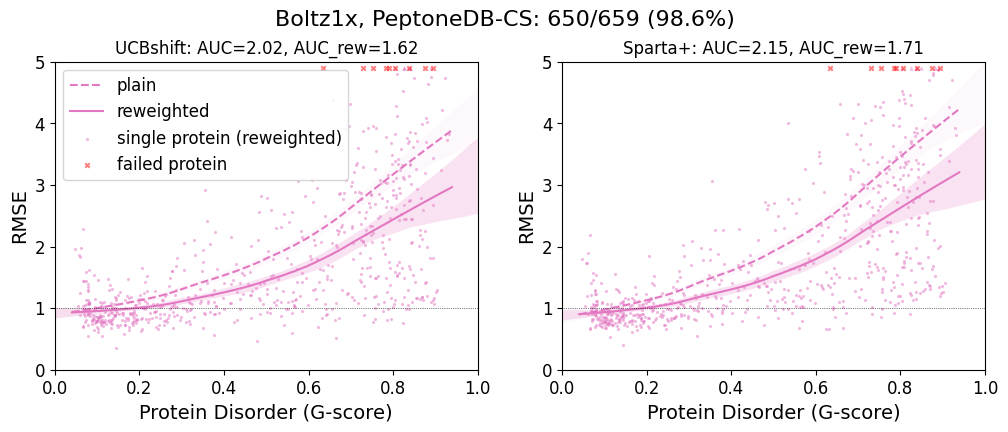

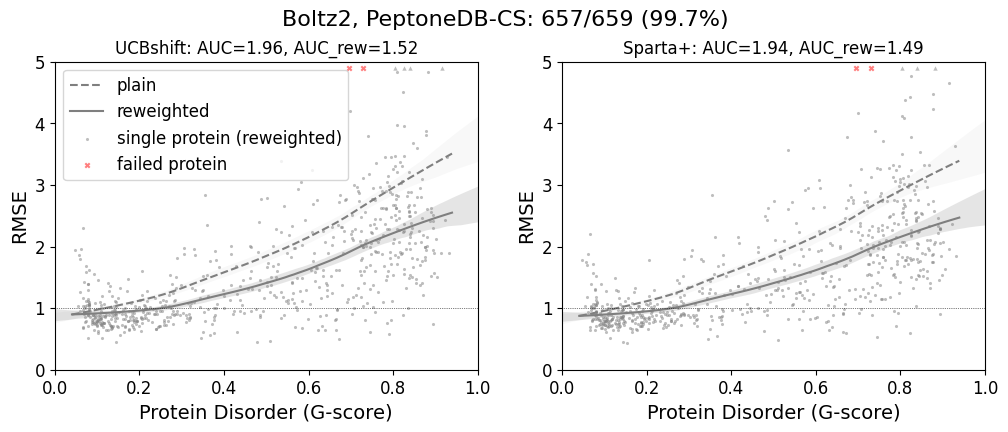

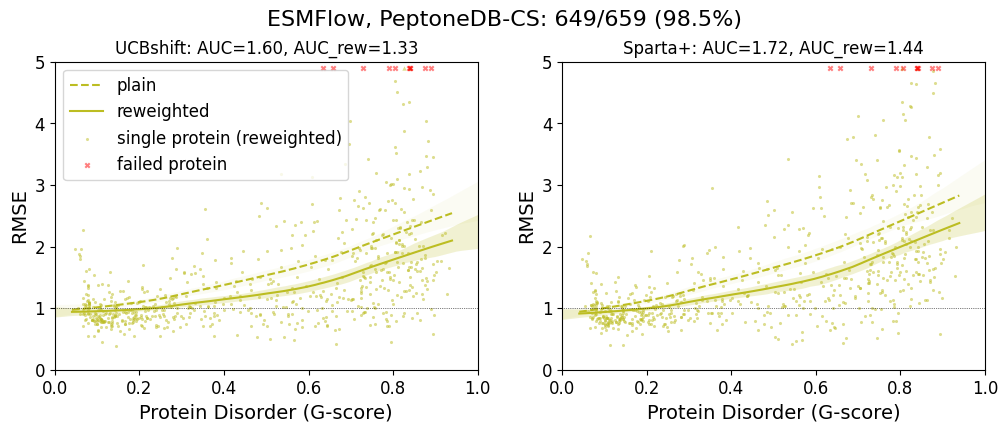

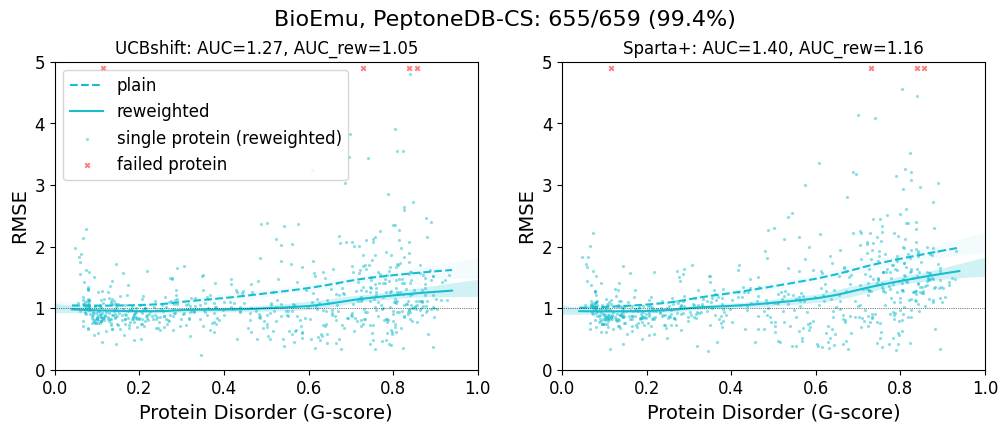

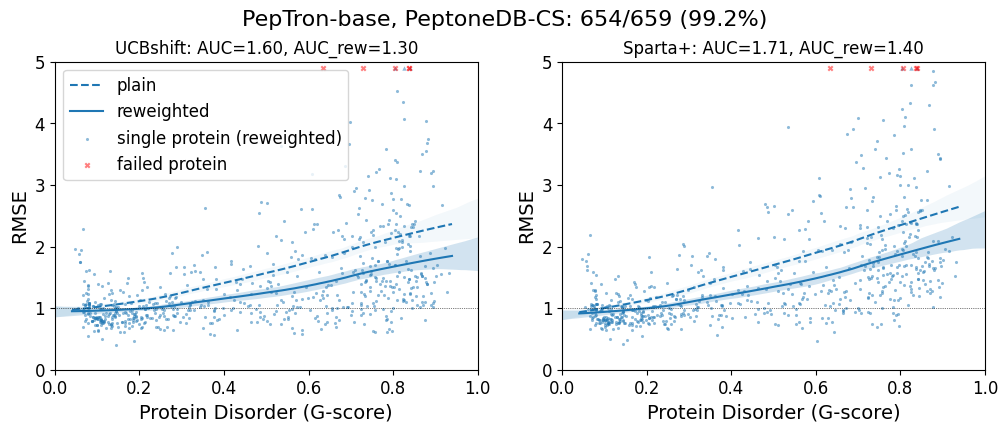

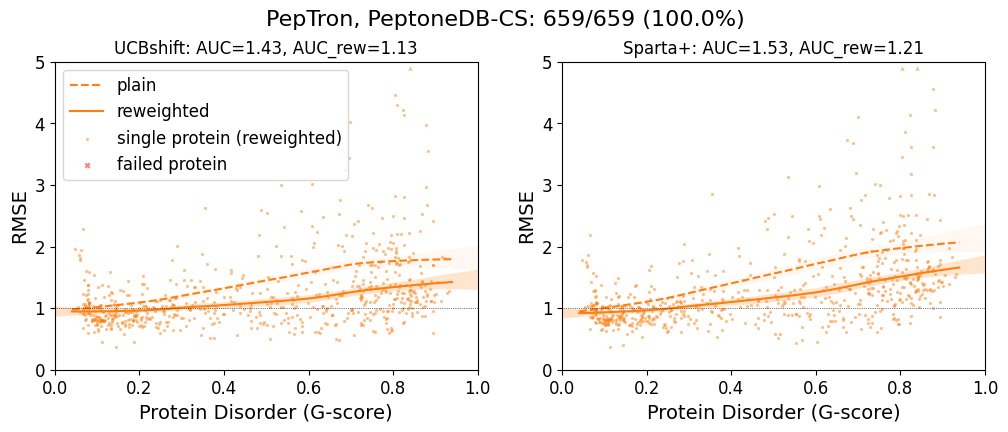

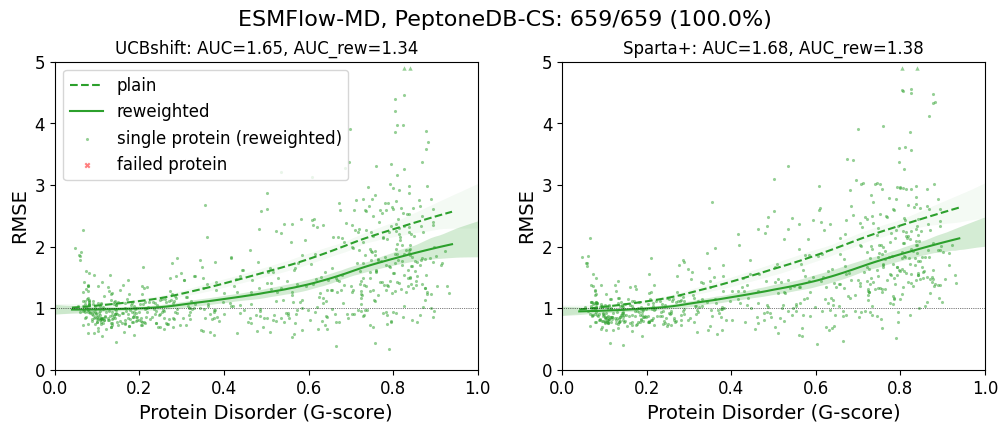

In [4]:
save_figures = False

lim_rmse_cs = 5.0  # 7.0
lim_rmse_saxs = 100.0
x_grid = np.linspace(0, 1, 100)
dx = x_grid[1] - x_grid[0]
for i, generator in enumerate(generators):
    plt.figure(figsize=(12, 4))
    for j, cs_tag in enumerate(["UCBshift", "Sparta+"]):
        plt.subplot(1, 2, j + 1)
        x = pep_cs_df.loc[info_cs[cs_tag][generator].index, "mean_gscore"].to_numpy()
        range_mask = (x.min() - dx < x_grid) & (x_grid < x.max() + dx)
        info = info_cs[cs_tag][generator]
        y = info["RMSE"].to_numpy()
        yfit, lower, upper = get_lowess_fit(x, y, xvals=x_grid)
        auc = yfit[range_mask].mean()
        plt.plot(x_grid[range_mask], yfit[range_mask], c=f"C{i}", ls="--", label="plain")
        plt.fill_between(x_grid, lower, upper, alpha=0.05, color=f"C{i}", lw=0)
        y = info["rew_RMSE"].to_numpy()
        if j == 0:
            plt.suptitle(
                f"{g_name[generator]}, PeptoneDB-CS: {sum(np.isfinite(y))}/{len(pep_cs_df)} ({sum(np.isfinite(y)) / len(pep_cs_df):.1%})",
                y=1.01,
            )
        yfit, lower, upper = get_lowess_fit(x, y, xvals=x_grid)
        plt.title(f"{cs_tag}: AUC={auc:.2f}, AUC_rew={yfit[range_mask].mean():.2f}")
        plt.plot(x_grid[range_mask], yfit[range_mask], c=f"C{i}", label="reweighted")
        plt.fill_between(x_grid, lower, upper, alpha=0.2, color=f"C{i}", lw=0)
        y_edge = 0.1
        outside_y = y >= lim_rmse_cs - y_edge
        plt.scatter(x[~outside_y], y[~outside_y], s=5, alpha=0.5, lw=0, c=f"C{i}", label="single protein (reweighted)")
        if sum(outside_y) > 0:
            plt.scatter(
                x[outside_y], [lim_rmse_cs - y_edge] * sum(outside_y), s=10, alpha=0.5, lw=0, c=f"C{i}", marker="^"
            )
        missing_labels = list(set(pep_cs_df.index) - set(info.index[np.isfinite(info["rew_RMSE"])]))
        if len(missing_labels) > 0:
            x = pep_cs_df.loc[missing_labels, "mean_gscore"].to_numpy()
            y = np.full(len(x), lim_rmse_cs - y_edge)
        else:  # for the legend
            x, y = [], []
        plt.scatter(x, y, s=10, alpha=0.5, c="r", marker="x", label="failed protein")
        plt.xlim(0, 1)
        plt.ylim(0, lim_rmse_cs)
        plt.xlabel("Protein Disorder (G-score)")
        plt.ylabel("RMSE")
        plt.axhline(1, color="k", ls=":", lw=0.5)
        if j == 0:
            plt.legend()

    if save_figures:
        plt.savefig(f"bench_{generator}.png", dpi=300, bbox_inches="tight")
    plt.show()

100%|██████████| 4/4 [00:00<00:00,  4.99it/s]


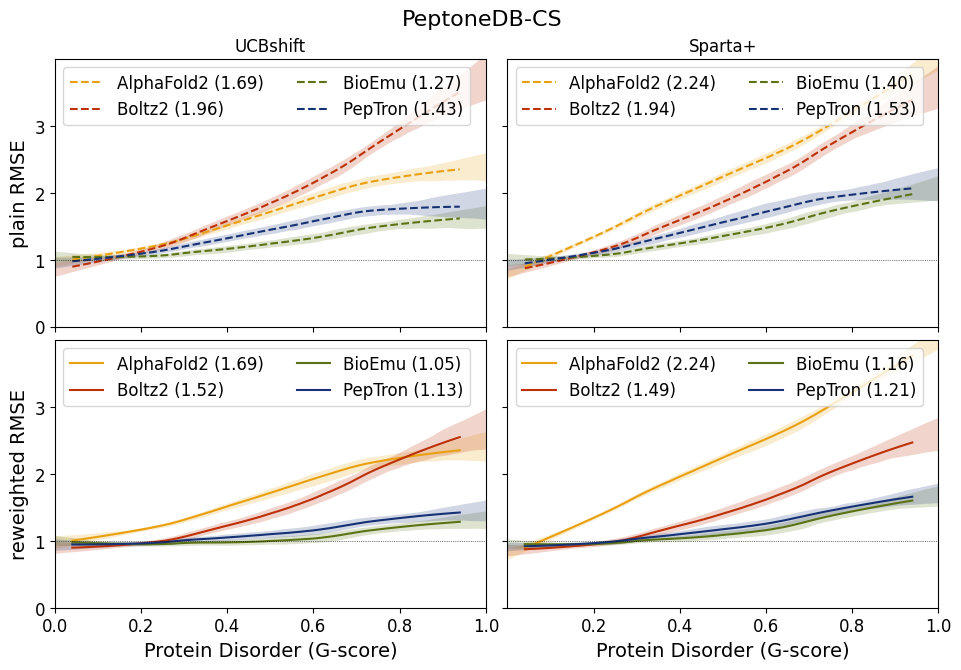

100%|██████████| 4/4 [00:00<00:00,  4.60it/s]


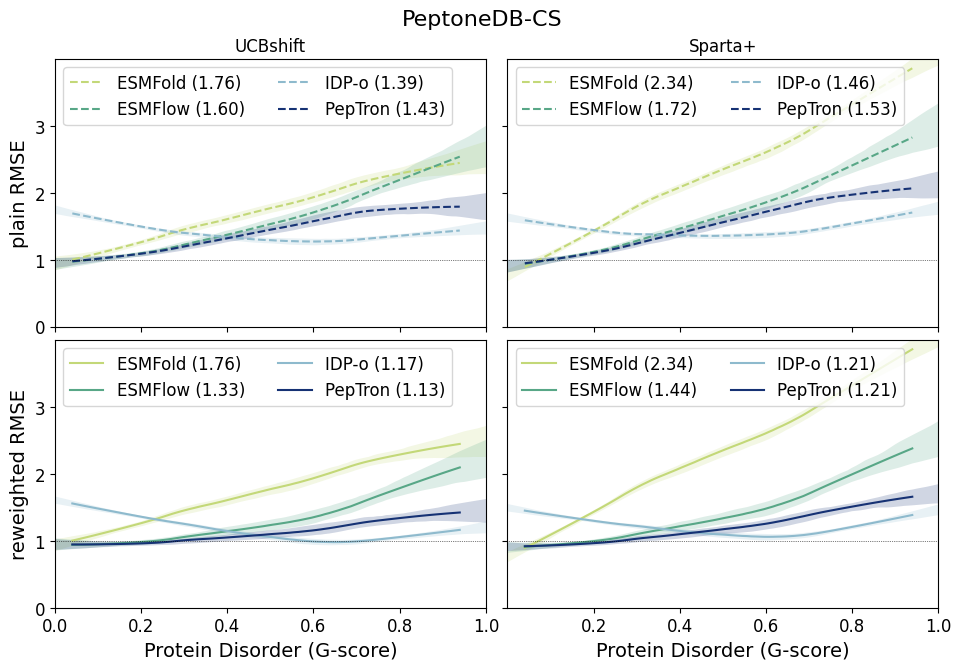

100%|██████████| 4/4 [00:00<00:00,  5.45it/s]


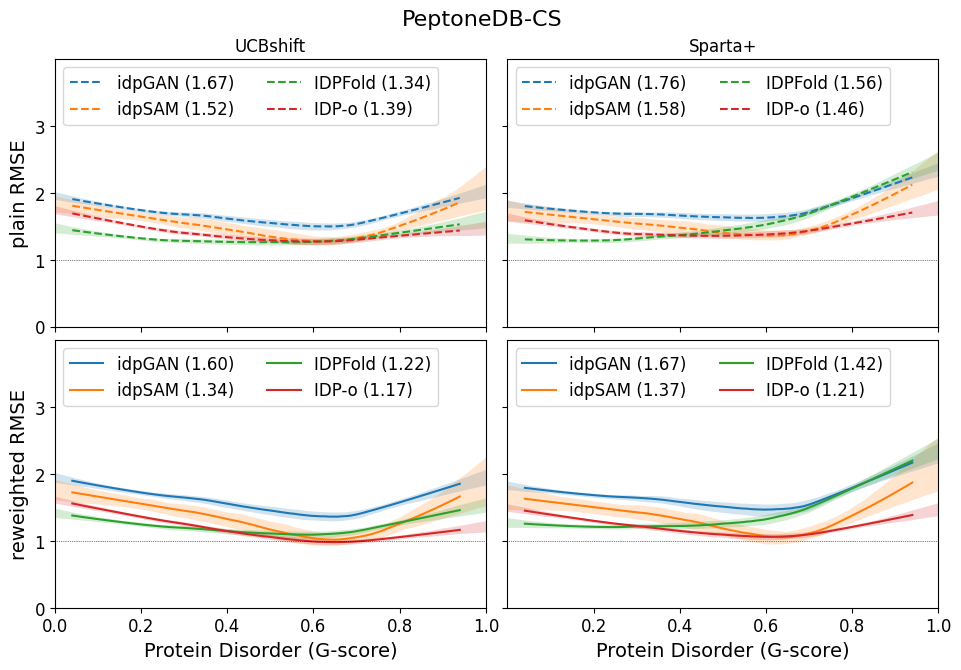

In [5]:
generators_sets = zip(
    ["pop", "esm", "idp"],
    [
        ["alphafold", "boltz2", "bioemu", "peptron_stable_pdb_idrome_20250812_256000"],
        ["esmfold", "esmflow", "idp-o", "peptron_stable_pdb_idrome_20250812_256000"],
        ["idpgan", "idpsam", "idpfold", "idp-o"],
    ],
)

save_figures = False
lim_rmse_cs = 4
s = 0.95

x_grid = np.linspace(0, 1, 100)
dx = x_grid[1] - x_grid[0]
for name, my_generators in generators_sets:
    if set(my_generators).issubset(colors.keys()):
        my_colors = colors
    else:
        my_colors = {g: f"C{i}" for i, g in enumerate(my_generators)}
    fig, axes = plt.subplots(2, 2, figsize=(12 * s, 7.5 * s))
    plt.suptitle("PeptoneDB-CS", y=0.95)
    plt.subplots_adjust(hspace=0.05, wspace=0.05)
    for k, (chosen_rmse, ls) in enumerate(zip(["RMSE", "rew_RMSE"], ["--", "-"])):
        ylabel = "plain RMSE" if chosen_rmse == "RMSE" else "reweighted RMSE"
        for j, cs_tag in enumerate(["UCBshift", "Sparta+"]):
            ax = axes[k, j]
            for generator in tqdm(my_generators):
                info = info_cs[cs_tag][generator]
                x = pep_cs_df.loc[info.index, "mean_gscore"].to_numpy()
                y = info[chosen_rmse].to_numpy()
                range_mask = (x.min() - dx < x_grid) & (x_grid < x.max() + dx)
                yfit, lower, upper = get_lowess_fit(x, y, xvals=x_grid)
                ax.plot(
                    x_grid[range_mask],
                    yfit[range_mask],
                    c=my_colors[generator],
                    ls=ls,
                    label=f"{g_name[generator]} ({np.nanmean(yfit[range_mask]):.2f})",
                )
                ax.fill_between(x_grid, lower, upper, alpha=0.2, color=my_colors[generator], lw=0)
            ax.set_xlim(x_grid.min(), x_grid.max())
            ax.set_ylim(0, lim_rmse_cs)
            ax.set_yticks(np.arange(0, int(np.ceil(lim_rmse_cs))))
            if j == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_yticklabels([])
                ax.set_xlim(x_grid.min() + 1e-8, x_grid.max())
            if k == 0:
                ax.set_title(f"{cs_tag}")
                ax.set_xticklabels([])
            else:
                ax.set_xlabel("Protein Disorder (G-score)")
            ax.axhline(1, color="k", ls=":", lw=0.5)
            ax.legend(ncol=2, loc="upper left")
    if save_figures:
        plt.savefig(f"CSbench-models_{name}.pdf", dpi=300, bbox_inches="tight")
    plt.show()